### Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


### Paths

In [2]:
TRAIN_DIR = Path("../processed/train")
VALID_DIR = Path("../processed/valid")
TEST_DIR = Path("../processed/test")

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

### Configuration

In [3]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 30

SEED = 42

### Load Dataset

#### Training

In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 3742 files belonging to 6 classes.


#### Validation

In [23]:
valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 801 files belonging to 6 classes.


#### Test

In [24]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 805 files belonging to 6 classes.


### Class Names

In [25]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['bacterial_leaf_blight', 'blast', 'brown_spot', 'healthy', 'leaf_scald', 'sheath_blight']
Number of classes: 6


### Data Augmentation

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

### Prefetch Dataset

In [27]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### Compute Class Weights

#### Extract Labels

In [28]:
labels = np.concatenate(
    [y.numpy() for x, y in train_ds],
    axis=0
)

#### Compute Weights

In [29]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    i: weights[i]
    for i in range(len(weights))
}

class_weights

{0: np.float64(1.029152915291529),
 1: np.float64(0.901252408477842),
 2: np.float64(0.9253214638971315),
 3: np.float64(1.0999412110523221),
 4: np.float64(1.0922358435493287),
 5: np.float64(0.9868143459915611)}

### Build MobileNetV2

In [30]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

### Build Final Model

In [31]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

### Compile Model

In [32]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Model Summary

In [34]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_1 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Callbacks

In [35]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="../models/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3
)

### Train Model

In [36]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 43s 338ms/step - accuracy: 0.4495 - loss: 1.4279 - val_accuracy: 0.5793 - val_loss: 1.0825 - learning_rate: 0.0010
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 39s 317ms/step - accuracy: 0.5975 - loss: 1.0506 - val_accuracy: 0.6567 - val_loss: 0.9116 - learning_rate: 0.0010
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 37s 315ms/step - accuracy: 0.6486 - loss: 0.9256 - val_accuracy: 0.7066 - val_loss: 0.8261 - learning_rate: 0.0010
Epoch 4/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 41s 317ms/step - accuracy: 0.6828 - loss: 0.8459 - val_accuracy: 0.7366 - val_loss: 0.7842 - learning_rate: 0.0010
Epoch 5/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 38s 321ms/step - accuracy: 0.6839 - loss: 0.8035 - val_accuracy: 0.7353 - val_loss: 0.7445 - learning_rate: 0.0010
Epoch 6/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 38s 325ms/step - accuracy: 0.7060 - loss: 0.7740 - val_accuracy: 0.7628 - val_loss: 0.7152 - learning_rate: 0.0010
Epoch 7/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 38s 322ms/step - accuracy: 0.7

### Save Final Model

In [37]:
model.save(
    "../models/agrolens_mobilenetv2.keras"
)

### Plot Accuracy

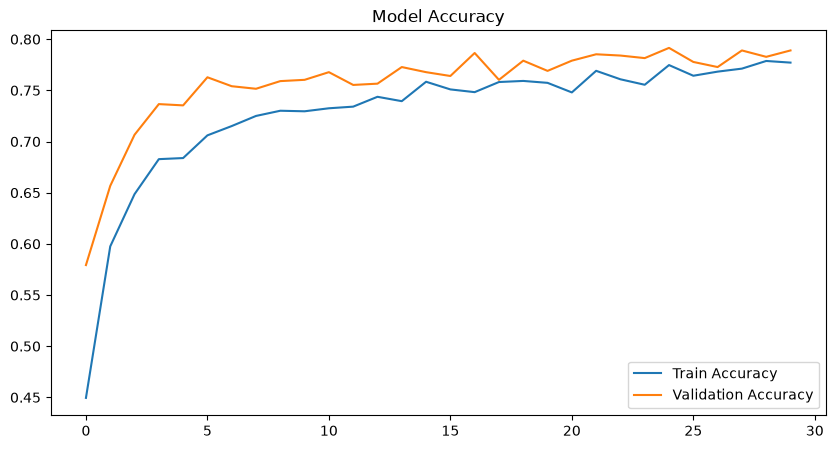

In [38]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Model Accuracy")

plt.show()

### Plot Loss

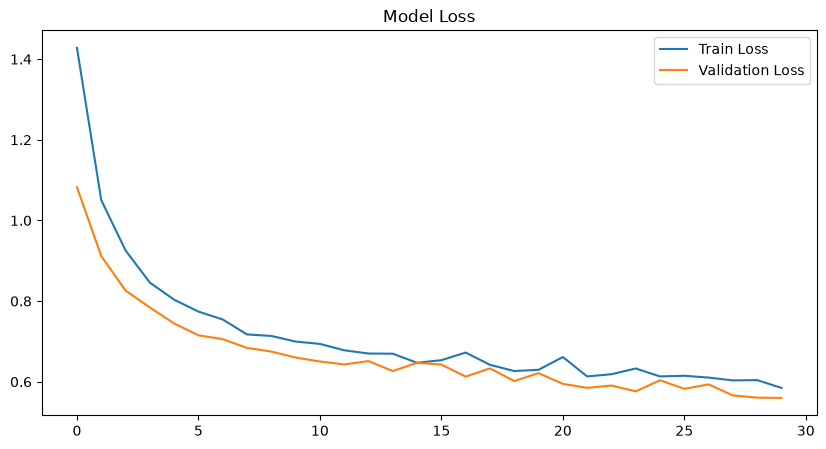

In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title("Model Loss")

plt.show()

### Evaluate on Test Set

In [40]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.8161 - loss: 0.5465
Test Accuracy: 0.8161490559577942
Test Loss: 0.5465342402458191
